In [ ]:
## Data handling
# Import Pandas for data handling and analysis
import pandas as pd
# Import NumPy for numerical analysis
import numpy as np

## Data Visualization 
# Import Matplotlib for visualization
from matplotlib import pyplot as plt
# Import Seaborn for advanved visualization
import seaborn as sns

## Model Building
# Import train_test_split to divide data into training and testing
from sklearn.model_selection import train_test_split
# Import OneHotEncoder to convert categorical data into numerical data
from sklearn.preprocessing import OneHotEncoder

from sklearn.preprocessing import StandardScaler
# Import LinearRegression model for prediction
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

## Pipeline Tools
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

## Advanced Models
from sklearn.ensemble import RandomForestRegressor

## Clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, precision_recall_fscore_support, davies_bouldin_score
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA


import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
# the .csv file should be on same folder as notebook
df = pd.read_csv('./car_sales_data.csv')

df

,Manufacturer,Model,Engine size,Fuel type,Year of manufacture,Mileage,Price
0,Ford,Fiesta,1.0,Petrol,2002,127300,3074
1,Porsche,718 Cayman,4.0,Petrol,2016,57850,49704
2,Ford,Mondeo,1.6,Diesel,2014,39190,24072
3,Toyota,RAV4,1.8,Hybrid,1988,210814,1705
4,VW,Polo,1.0,Petrol,2006,127869,4101
...,...,...,...,...,...,...,...
49995,BMW,M5,5.0,Petrol,2018,28664,113006
49996,Toyota,Prius,1.8,Hybrid,2003,105120,9430
49997,Ford,Mondeo,1.6,Diesel,2022,4030,49852
49998,Ford,Focus,1.0,Diesel,2016,26468,23630


In [3]:
# shows (count, mean, standard deviation etc) for numerical column
# (.T) used to transpose index and column of the dataframe for better understanding
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Engine size,50000.0,1.773058,0.734108,1.0,1.40,1.6,2.0,5.0
Year of manufacture,50000.0,2004.209440,9.645965,1984.0,1996.00,2004.0,2012.0,2022.0
Mileage,50000.0,112497.320700,71632.515602,630.0,54352.25,100987.5,158601.0,453537.0
Price,50000.0,13828.903160,16416.681336,76.0,3060.75,7971.5,19026.5,168081.0


In [4]:
# checking each columns data type and to understand structure of dataset
print(df.dtypes)

Manufacturer            object
Model                   object
Engine size            float64
Fuel type               object
Year of manufacture      int64
Mileage                  int64
Price                    int64
dtype: object


In [5]:
# Missing values before cleaning
print("MISSING VALUES PER COLUMN BEFORE:")
print(df.isnull().sum())

# Define numerical and categorical columns
num_col = ["Engine size", "Year of manufacture", "Mileage", "Price"]
cat_col = ["Manufacturer", "Model", "Fuel type"]

# Missing value handle (Numeric column)
#calculating median
medians = df[num_col].median()
# Filling missing values
df = df.fillna(medians)

# Missing value handle (Categoric column)
# Filling missing values
df[cat_col] =df[cat_col].fillna("Unknown")

# Check missing values after cleaning
print("MISSING VALUES PER COLUMN AFTER:")
print(df.isnull().sum())

MISSING VALUES PER COLUMN BEFORE:
Manufacturer           0
Model                  0
Engine size            0
Fuel type              0
Year of manufacture    0
Mileage                0
Price                  0
dtype: int64
MISSING VALUES PER COLUMN AFTER:
Manufacturer           0
Model                  0
Engine size            0
Fuel type              0
Year of manufacture    0
Mileage                0
Price                  0
dtype: int64


In [6]:
'''This function measures the quality(r^2) and accuracy(RMSE) of the model'''
def evaluate_model(y_true, y_pred):
    # R^2 = Coefficient of Determination
    # R2 how well model explains variance (higher is better)
    r2 = r2_score(y_true, y_pred)
    
    #RMSE = Root Mean Squared Error
    # RMSE average prediction error (lower is better)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # MAE is the average absolute dufference (lower is better)
    mae = mean_absolute_error(y_true, y_pred)
    return r2, mae, rmse

In [7]:
# independent variable
X_features = ["Engine size" , "Mileage" , "Year of manufacture"]
# dependent variable
target = "Price"

# to store result in a list
results = []

# Assign X and y for test and train
for feature in X_features:
    x_temp = df[[feature]]
    y_temp =df[target]

    # Split data into training and test set (80% train, 20% test)
    x_train , x_test , y_train, y_test = train_test_split(
        x_temp, y_temp , test_size=0.2 , random_state=42
    )

    # Standardization 
    scaler = StandardScaler()
    x_train_scaled = scaler.fit_transform(x_train)
    x_test_scaled = scaler.transform(x_test)

    # Linear regression
    linear_model = LinearRegression()
    linear_model.fit(x_train_scaled , y_train)
    y_linear_predict = linear_model.predict(x_test_scaled)

    # Evaluate
    r2_lin, mae_lin, rmse_lin  = evaluate_model(y_test, y_linear_predict)

    # polynomial regression(Degree=3)
    poly = PolynomialFeatures(degree=3, include_bias=False)
    X_poly_train = poly.fit_transform(x_train_scaled)
    X_poly_test = poly.transform(x_test_scaled)

    poly_model = LinearRegression()
    poly_model.fit(X_poly_train,y_train)
    y_poly_predict = poly_model.predict(X_poly_test)

    # Evaluate
    r2_poly, mae_poly, rmse_poly = evaluate_model(y_test,y_poly_predict)

    # Store results
    results.append([feature, r2_lin, mae_lin, rmse_lin, r2_poly, mae_poly, rmse_poly])

# Convert results to dataframe
results_df = pd.DataFrame(results,columns=["Feature",
                                           "R2 Linear","MAE Linear","RMSE Linear",
                                           "R2 Polynomial", "MAE Polynomial", "RMSE Polynomial"] )
(results_df).round(4)

,Feature,R2 Linear,MAE Linear,RMSE Linear,R2 Polynomial,MAE Polynomial,RMSE Polynomial
0,Engine size,0.1506,10817.4916,15182.1986,0.1522,10802.8690,15168.2575
1,Mileage,0.4013,7964.7847,12746.3158,0.5500,5815.6694,11050.9386
2,Year of manufacture,0.5111,7031.0392,11518.6371,0.6203,5186.8689,10151.0348


**Check the best model**

In [8]:
best_models = {}

for i, row in results_df.iterrows():
    feature = row["Feature"]
    
    # Choose model with higher R2
    if row["R2 Polynomial"] > row["R2 Linear"]:
        best_models[feature] = "Polynomial"
    else:
        best_models[feature] = "Linear"

print(best_models)

{'Engine size': 'Polynomial', 'Mileage': 'Polynomial', 'Year of manufacture': 'Polynomial'}


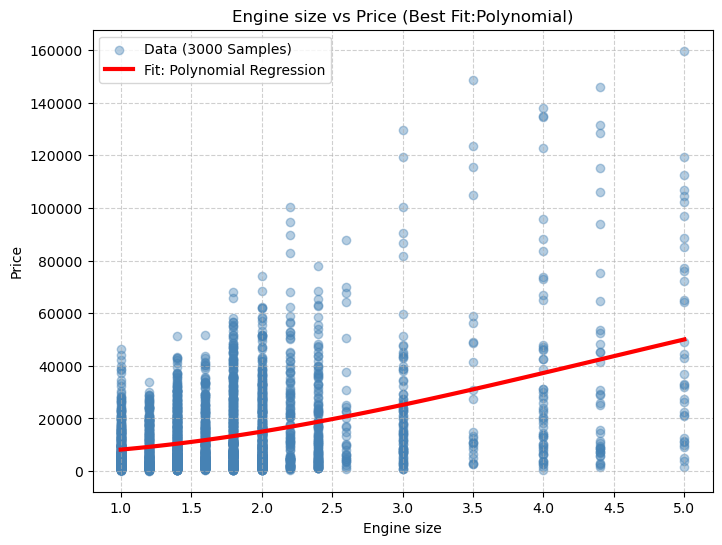

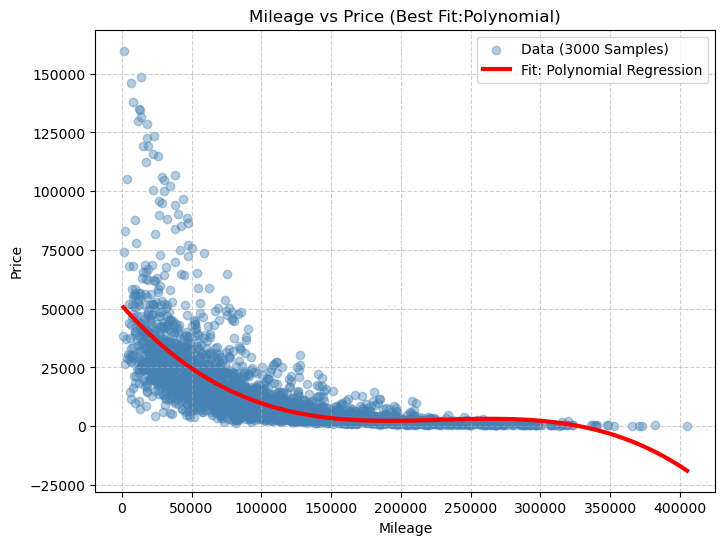

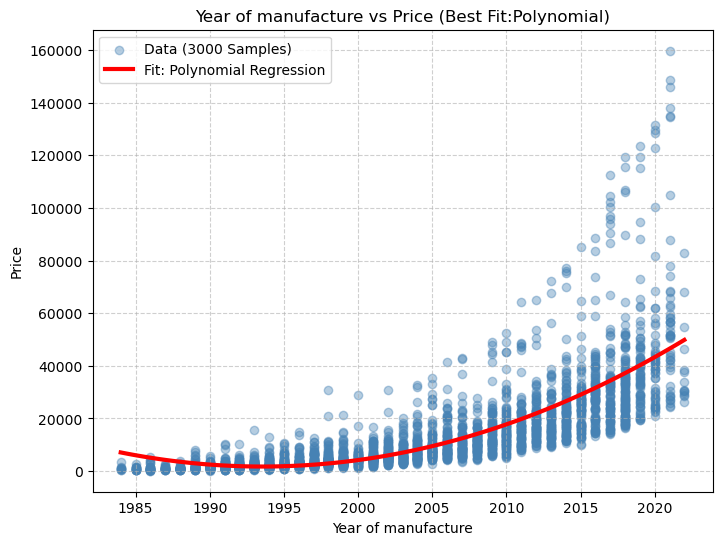

In [9]:
# get sample of 3000 data point
df_sample = df.sample(n=3000, random_state=42)

for feature in X_features:
    # Use only the SAMPLE for X and y
    X_sample = df_sample[[feature]]
    y_sample = df_sample["Price"]
    
    # Create smooth X range based on the sample's min/max
    X_range_raw = np.linspace(X_sample[feature].min(), X_sample[feature].max(), 100).reshape(-1, 1)
    X_range = pd.DataFrame(X_range_raw, columns=[feature])
    
    # Identify best model for this feature 
    if best_models[feature] == "Linear":
        model = LinearRegression()
        # Train on the sample
        model.fit(X_sample, y_sample)
        
        y_line = model.predict(X_range)
        model_name = "Linear Regression"
        
    else:
        poly = PolynomialFeatures(degree=3)
        # Transform the sample data
        X_poly_sample = poly.fit_transform(X_sample)
        X_range_poly = poly.transform(X_range)
        model = LinearRegression()

        # Train
        model.fit(X_poly_sample, y_sample)

        # Predict
        y_line = model.predict(X_range_poly)
        model_name = "Polynomial Regression"
    
    # Plotting 
    plt.figure(figsize=(8,6))
    
    # Scatter
    plt.scatter(X_sample, y_sample, alpha=0.4, color='steelblue', label='Data (3000 Samples)')
    plt.plot(X_range, y_line, color="red", linewidth=3, label=f"Fit: {model_name}")

    # labels and title
    plt.xlabel(feature)
    plt.ylabel("Price")
    plt.title(f"{feature} vs Price (Best Fit:{best_models [feature]})")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    
    plt.show()

In [10]:
# multiple numerical features altogether
X = df[["Engine size","Mileage","Year of manufacture"]]
y = df[["Price"]]

# split data into training and test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# train model
multi_linear = LinearRegression()
multi_linear.fit(X_train, y_train)

# predict
y_multi_predict = multi_linear.predict(X_test)

# evaluate
r2_multi, mae_multi, rmse_multi = evaluate_model(y_test, y_multi_predict)

print("Multiple regression R2: ", r2_multi)
print("Multiple regression MAE: ", mae_multi)
print("Multiple regression RMSE: ", rmse_multi)

Multiple regression R2:  0.671456306417368
Multiple regression MAE:  6091.458141656289
Multiple regression RMSE:  9442.38400829851


In [11]:
# seperate categorical and numerical feature
categorical_feat = ["Manufacturer", "Model", "Fuel type"]
numerical_feat = ["Engine size", "Year of manufacture", "Mileage"]

# spliting features and target
X_full = df[categorical_feat+numerical_feat]
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, random_state=42
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", 'passthrough', numerical_feat),
        ("category", OneHotEncoder(handle_unknown="ignore"), categorical_feat)    
])

# Combine into single pipeline
random_forest_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("regressor", RandomForestRegressor(n_estimators=100, random_state=42, max_depth=15))
])

print(f"Training set: {X_train.shape[0]} cars \nTest set: {X_test.shape[0]} cars")

# train model 
random_forest_pipeline.fit(X_train,y_train)
print("Model Trained")

# predict
y_rf_predict = random_forest_pipeline.predict(X_test)

# evaluate
r2_rf, mae_rf, rmse_rf = evaluate_model(y_test, y_rf_predict)

print("\nRESULTS -")
print("Random Forest (R²): ", r2_rf)
print("Random Forest (MAE): ", mae_rf)
print("Random Forest (RMSE): ", rmse_rf)

Training set: 40000 cars 
Test set: 10000 cars
Model Trained

RESULTS -
Random Forest (R²):  0.9982041903683284
Random Forest (MAE):  370.0672882042699
Random Forest (RMSE):  698.0961441016577


In [12]:
# Fit and transform train dataset
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# total input number of features for preprocessing
input_dimension = X_train_processed.shape[1]
input_dimension

26

In [13]:
#sequential model using with 2 hidden layers
model = Sequential(
    [
        Input(shape=(input_dimension,)),
        Dense(64, activation="relu"),
        Dense(64,activation="relu"),
        Dense(1,activation="linear")
    ]
)

#build and compile the model
model.compile(
    optimizer="Adam",
    loss="mean_squared_error",
    metrics=['mean_absolute_error']
)

In [14]:
# validation loss detecting by using early stopping 

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# train ann model
train_model = model.fit(
    X_train_processed,
    y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=200,
    verbose="auto",
    callbacks=[early_stop]
)

Epoch 1/200
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 405616896.0000 - mean_absolute_error: 12716.9775 - val_loss: 270851648.0000 - val_mean_absolute_error: 10036.2109
Epoch 2/200
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 181097104.0000 - mean_absolute_error: 7097.0767 - val_loss: 123585312.0000 - val_mean_absolute_error: 5931.3965
Epoch 3/200
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 126685080.0000 - mean_absolute_error: 6124.1870 - val_loss: 122023320.0000 - val_mean_absolute_error: 6387.6426
Epoch 4/200
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 124952504.0000 - mean_absolute_error: 6114.5332 - val_loss: 121013632.0000 - val_mean_absolute_error: 5893.9824
Epoch 5/200
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 124486536.0000 - mean_absolute_error: 6082.6787 - val_loss: 120607256.0000 - val_mean_absolute_error: 6293.0605
Epoch 6/200
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 124102584.0000 - mean_absolute_error: 6070.9766 - val_loss: 123175584.00

In [15]:
# evaluate model
y_predict_ann = model.predict(preprocessor.transform(X_test)).flatten()

ann_r2, ann_mae, ann_rmse = evaluate_model(y_test, y_predict_ann)


print("ann_r2", ann_r2)
print("ann_mae", ann_mae)
print("ann_rmse", ann_rmse)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 810us/step
ann_r2 0.8597984313964844
ann_mae 3403.510498046875
ann_rmse 6168.243510108854


In [16]:
# SMALL ANN TUNING (NEURONS)

neuron_results = []

for n in [32, 64, 128]:
    
    model = Sequential([
        Input(shape=(input_dimension,)),
        Dense(n, activation="relu"),
        Dense(n, activation="relu"),
        Dense(1, activation="linear")
    ])
    
    model.compile(optimizer="adam", loss="mse")

    model.fit(
        X_train_processed,
        y_train,
        epochs=30,
        batch_size=200,
        validation_split=0.2,
        verbose=0
    )

    y_pred = model.predict(preprocessor.transform(X_test)).flatten()
    r2, mae, rmse = evaluate_model(y_test, y_pred)

    neuron_results.append([n, r2, mae, rmse])

# Convert to DataFrame for reporting
ann_tuning_df = pd.DataFrame(
    neuron_results,
    columns=["Neurons per layer", "R2", "MAE", "RMSE"]
)

display(ann_tuning_df.round(4))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 746us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 922us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 885us/step


,Neurons per layer,R2,MAE,RMSE
0,32,0.5666,5864.7622,10844.8056
1,64,0.5727,5535.8711,10768.0884
2,128,0.5721,6536.0742,10776.1522


In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

# ---------------------------
# Create price bands
# ---------------------------
low_thr, high_thr = df["Price"].quantile([0.33, 0.66])

def price_band(p):
    if p < low_thr:
        return "Low"
    elif p < high_thr:
        return "Medium"
    else:
        return "High"


# ---------------------------
# Convert true values once
# ---------------------------
y_test_band = np.array([price_band(p) for p in y_test])


# ---------------------------
# Accuracy function
# ---------------------------
'''Converts predicted prices into categories (Low, Medium, High) and measures how often they match the true categories.'''
def get_accuracy(y_true, y_pred):
    y_pred_band = np.array([price_band(p) for p in y_pred])
    return accuracy_score(y_true, y_pred_band)


# ---------------------------
# Confusion matrix plot function
# ---------------------------
'''Creates and displays a confusion matrix for model’s predictions and calculates its accuracy.'''
def plot_cm(y_true_band, y_pred_price, model_name):
    
    y_pred_band = np.array([price_band(p) for p in y_pred_price])
    
    accuracy = accuracy_score(y_true_band, y_pred_band)
    
    cm = confusion_matrix(
        y_true_band,
        y_pred_band,
        labels=["Low", "Medium", "High"]
    )
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Low", "Medium", "High"]
    )
    
    disp.plot(cmap="Blues", values_format="d")
    plt.title(f"{model_name} (Accuracy: {accuracy:.3f})")
    plt.tight_layout()
    plt.show()
    
    return accuracy


# ---------------------------
# Store results cleanly
# ---------------------------
confusion_results = []

confusion_results.append([
    "Single Feature",
    get_accuracy(y_test_band, y_linear_predict)
])

confusion_results.append([
    "Multiple Linear",
    get_accuracy(y_test_band, y_multi_predict.flatten())
])

confusion_results.append([
    "Random Forest",
    get_accuracy(y_test_band, y_rf_predict)
])

confusion_results.append([
    "ANN",
    get_accuracy(y_test_band, y_predict_ann)
])


# ---------------------------
# Convert to dataframe
# ---------------------------
confusion_summary_df = pd.DataFrame(
    confusion_results,
    columns=["Model", "Accuracy"]
)

display(confusion_summary_df.round(4))

,Model,Accuracy
0,Single Feature,0.6912
1,Multiple Linear,0.7605
2,Random Forest,0.9777
3,ANN,0.8239


In [18]:
def show_class_metrics(name, y_true, y_pred):
    
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=["Low", "Medium", "High"],
        zero_division=0
    )
    
    print(f"\n{name}")
    print("-" * 40)
    
    classes = ["Low", "Medium", "High"]
    
    for i, cls in enumerate(classes):
        print(f"{cls}")
        print(" Precision:", round(precision[i], 3))
        print(" Recall:   ", round(recall[i], 3))
        print(" F1-score: ", round(f1[i], 3))
        print(" Support:  ", support[i])
        print("-" * 40)


# Convert predictions to bands and evaluate

# Single Feature
show_class_metrics(
    "Single Feature",
    y_test_band,
    [price_band(p) for p in y_linear_predict]
)

# Multiple Linear Regression
show_class_metrics(
    "Multiple Linear",
    y_test_band,
    [price_band(p) for p in y_multi_predict.flatten()]
)

# 3. Random Forest
show_class_metrics(
    "Random Forest",
    y_test_band,
    [price_band(p) for p in y_rf_predict]
)

# 4. ANN
show_class_metrics(
    "ANN",
    y_test_band,
    [price_band(p) for p in y_predict_ann]
)


Single Feature
----------------------------------------
Low
 Precision: 0.884
 Recall:    0.694
 F1-score:  0.778
 Support:   3364
----------------------------------------
Medium
 Precision: 0.546
 Recall:    0.412
 F1-score:  0.469
 Support:   3280
----------------------------------------
High
 Precision: 0.66
 Recall:    0.962
 F1-score:  0.783
 Support:   3356
----------------------------------------

Multiple Linear
----------------------------------------
Low
 Precision: 0.96
 Recall:    0.775
 F1-score:  0.858
 Support:   3364
----------------------------------------
Medium
 Precision: 0.694
 Recall:    0.502
 F1-score:  0.583
 Support:   3280
----------------------------------------
High
 Precision: 0.682
 Recall:    0.999
 F1-score:  0.81
 Support:   3356
----------------------------------------

Random Forest
----------------------------------------
Low
 Precision: 0.988
 Recall:    0.977
 F1-score:  0.982
 Support:   3364
----------------------------------------
Medium
 Prec

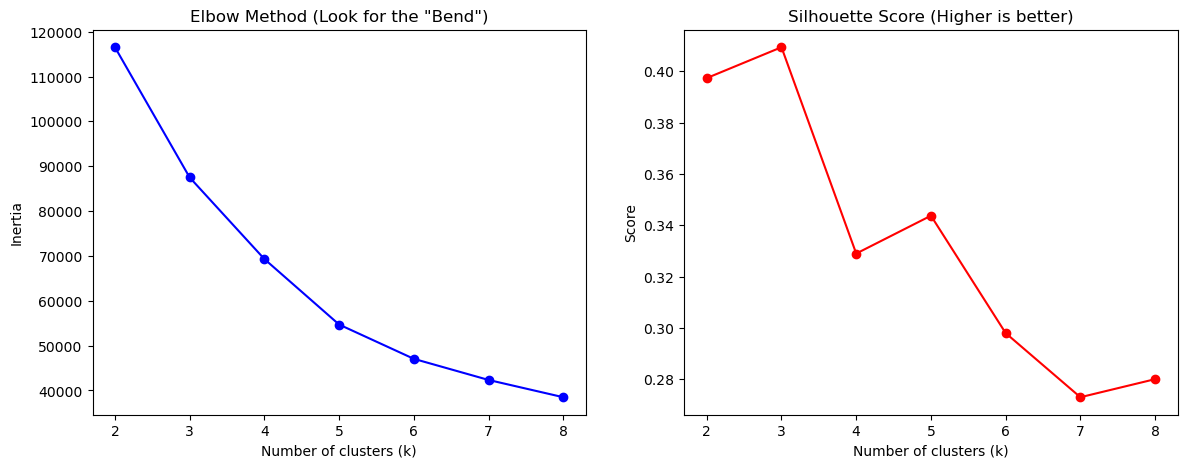

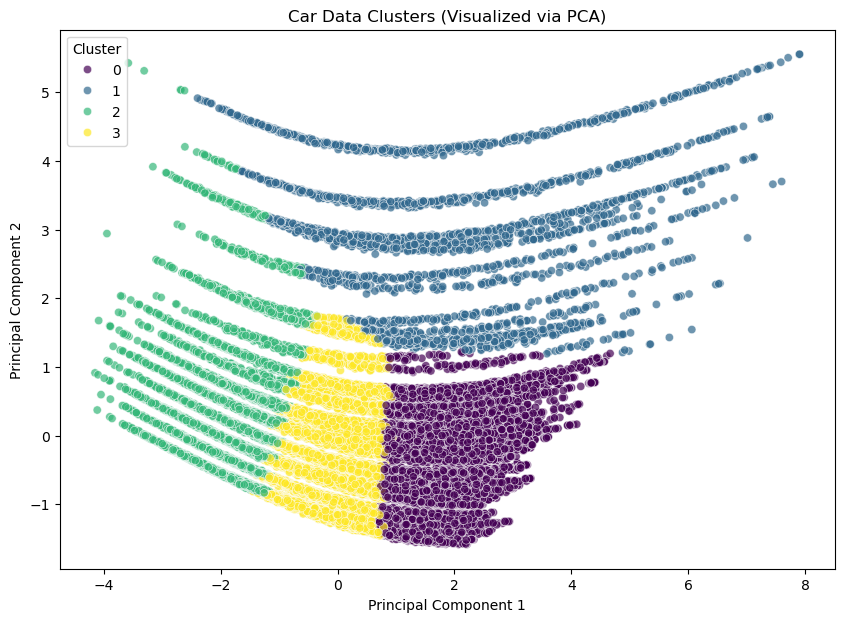


=== CLUSTER PROFILES (Means) ===


,Engine size,Year of manufacture,Mileage,Price
Cluster,,,,
0,1.64,2015.60,40368.35,27854.71
1,3.93,2007.64,87422.45,42292.04
2,1.70,1993.27,200825.59,2125.98
3,1.58,2003.74,101796.04,8095.38



Number of cars per cluster:
Cluster
0    13540
1     3046
2    14244
3    19170
Name: count, dtype: int64


In [19]:
# Select Numerical Features for Clustering
X_cluster = df[["Engine size", "Year of manufacture", "Mileage", "Price"]]

## K-Means is distance-based, so scaling is mandatory
#  Scale the data 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Optimal k using (Elbow + Silhouette methods)
k_range = range(2, 9)
inertias = []
silhouette_avg = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_avg.append(silhouette_score(X_scaled, labels))

# Plotting Evaluation Metrics
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Plot
ax1.plot(k_range, inertias, marker='o', color='blue')
ax1.set_title('Elbow Method (Look for the "Bend")')
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Inertia')

# Silhouette Plot
ax2.plot(k_range, silhouette_avg, marker='o', color='red')
ax2.set_title('Silhouette Score (Higher is better)')
ax2.set_xlabel('Number of clusters (k)')
ax2.set_ylabel('Score')
plt.show()

# Final K-Means(based on evaluation)
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(X_scaled)

# Visualize Clusters using PCA (Principal Component Analysis) to reduce dimensions to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['Cluster'], palette='viridis', alpha=0.7)
plt.title('Car Data Clusters (Visualized via PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.savefig('car_clusters_pca.png')  # Savefigure
plt.show()

# Show Cluster Profiles (this shows the mean values of numerical features per cluster)
print("\n=== CLUSTER PROFILES (Means) ===")
display(df.groupby('Cluster')[["Engine size", "Year of manufacture", "Mileage", "Price"]].mean().round(2))

print("\nNumber of cars per cluster:")
print(df['Cluster'].value_counts().sort_index())

=== K-MEANS CLUSTERING RESULTS ===

Engine + Price
k | Inertia | Silhouette
------------------------------
2 | 57275.8 | 0.621
3 | 41559.1 | 0.475
4 | 29386.53 | 0.492
5 | 21668.85 | 0.432
6 | 17635.01 | 0.436


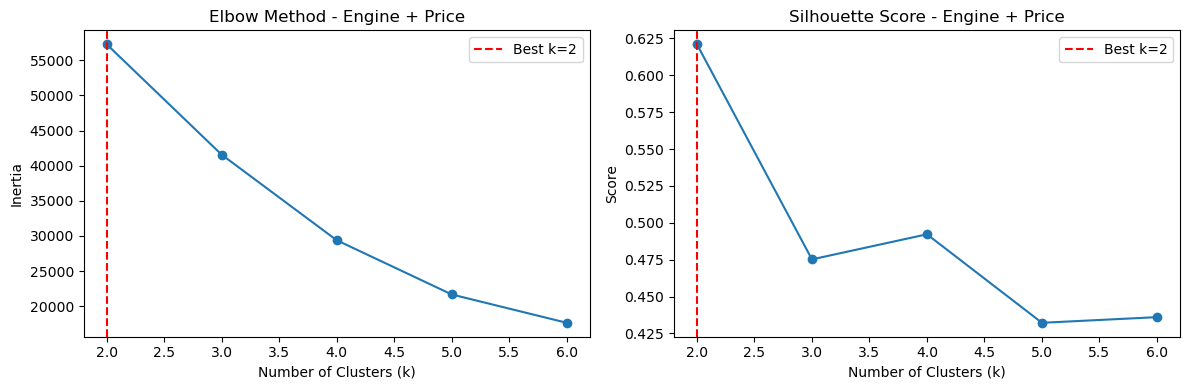

Best k: 2
Best Silhouette Score: 0.621

Mileage + Price
k | Inertia | Silhouette
------------------------------
2 | 49096.81 | 0.487
3 | 29351.66 | 0.478
4 | 19634.34 | 0.471
5 | 13958.44 | 0.453
6 | 10751.65 | 0.438


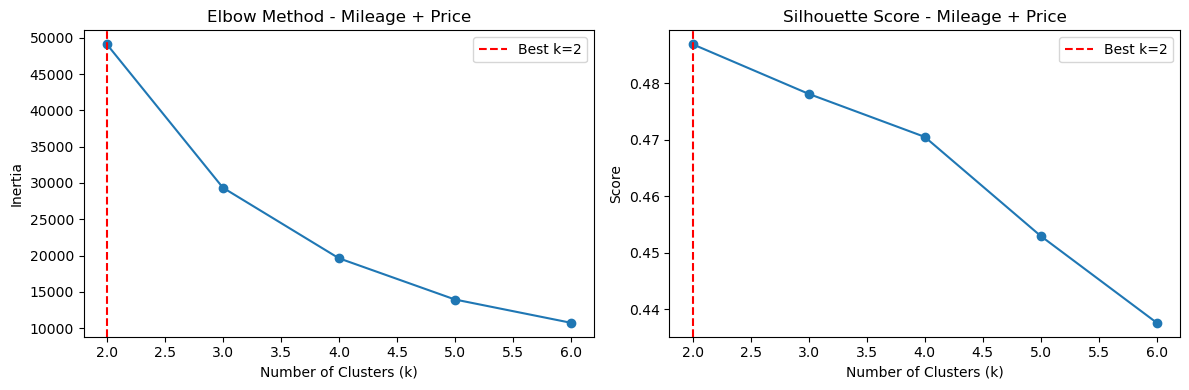

Best k: 2
Best Silhouette Score: 0.487

Year + Mileage
k | Inertia | Silhouette
------------------------------
2 | 35731.13 | 0.533
3 | 21476.83 | 0.465
4 | 15777.52 | 0.42
5 | 13082.16 | 0.381
6 | 10588.39 | 0.397


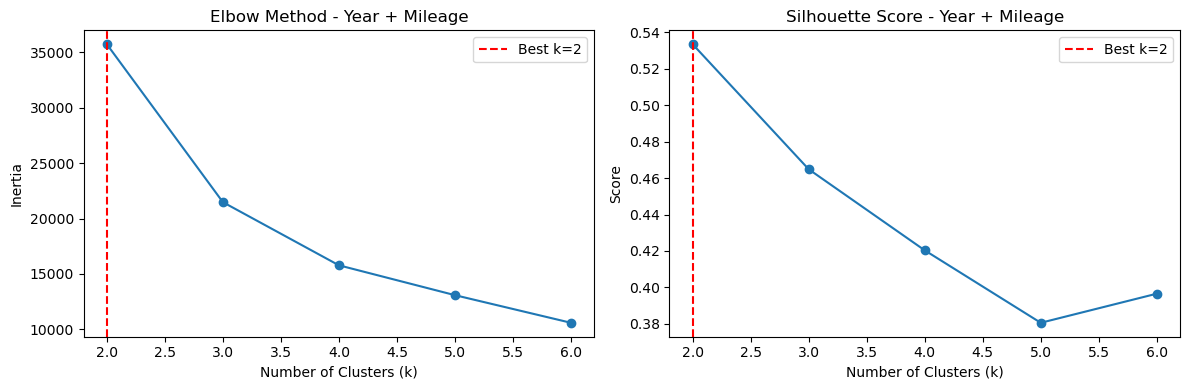

Best k: 2
Best Silhouette Score: 0.533

All Numerical
k | Inertia | Silhouette
------------------------------
2 | 85731.18 | 0.403
3 | 58048.49 | 0.44
4 | 44685.53 | 0.352
5 | 39371.47 | 0.289
6 | 35281.63 | 0.275


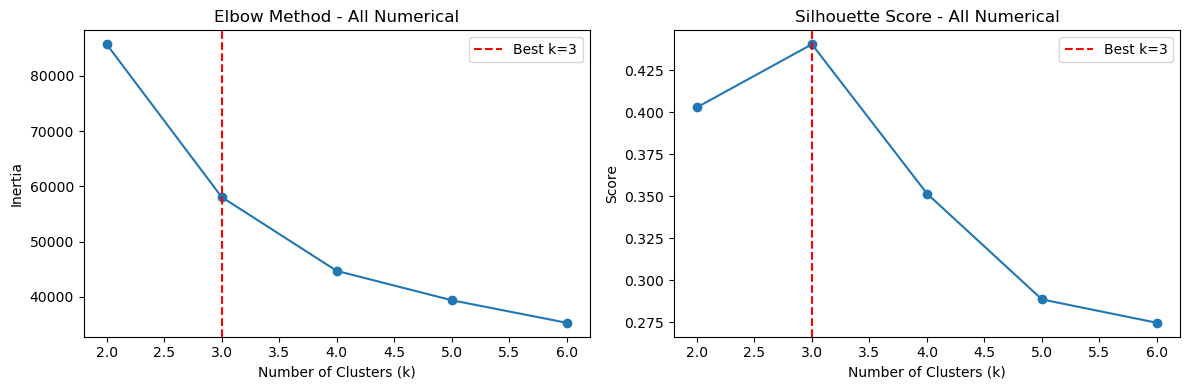

Best k: 3
Best Silhouette Score: 0.44

=== FINAL RESULTS ===


,Feature Set,Best k,Silhouette Score,Samples
0,Engine + Price,2,0.621,50000
2,Year + Mileage,2,0.533,50000
1,Mileage + Price,2,0.487,50000
3,All Numerical,3,0.440,50000


In [20]:
'''A function to run K-Means with detailed output and plots'''
def run_kmeans_with_details(X_scaled, name, k_min=2, k_max=6):
    inertias = []
    silhouettes = [] 
    k_values = range(k_min, k_max + 1)
    
    print(f"\n{name}")
    print("k | Inertia | Silhouette")
    print("-" * 30)
    
    # Loop through k values and compute metrics
    for k in k_values:
        model = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = model.fit_predict(X_scaled)
        
        inertia = model.inertia_
        silhouette = silhouette_score(X_scaled, labels)
        
        inertias.append(inertia)
        silhouettes.append(silhouette)
        
        print(f"{k} | {round(inertia,2)} | {round(silhouette,3)}")
    
    # Identify best k based on silhouette score
    best_k = k_values[np.argmax(silhouettes)]
    best_score = max(silhouettes)
    
    # Plotting
    plt.figure(figsize=(12,4))
    
    # Elbow plot
    plt.subplot(1,2,1)
    plt.plot(k_values, inertias, marker='o')
    plt.axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
    plt.title(f'Elbow Method - {name}')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Inertia')
    plt.legend()
    
    # Silhouette plot
    plt.subplot(1,2,2)
    plt.plot(k_values, silhouettes, marker='o')
    plt.axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
    plt.title(f'Silhouette Score - {name}')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Score')
    plt.legend()
    plt.savefig(f'kmeans_evaluation_{name.replace(" ", "_")}.png')  # Save figure
    
    plt.tight_layout()
    plt.show()
    
    print(f"Best k: {best_k}")
    print(f"Best Silhouette Score: {round(best_score,3)}")
    
    return best_k, best_score


# Define different feature sets for clustering and evaluate
cluster_sets = {
    "Engine + Price": ["Engine size", "Price"],
    "Mileage + Price": ["Mileage", "Price"],
    "Year + Mileage": ["Year of manufacture", "Mileage"],
    "All Numerical": ["Engine size", "Year of manufacture", "Mileage"]
}

results = []

print("=== K-MEANS CLUSTERING RESULTS ===")

for name, features in cluster_sets.items():
    
    X_cluster = df[features].dropna()
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_cluster)
    
    best_k, best_score = run_kmeans_with_details(X_scaled, name)
    
    results.append([name, best_k, round(best_score, 3), len(X_cluster)])


# Create results dataframe for better visualization
results_df = pd.DataFrame(
    results,
    columns=["Feature Set", "Best k", "Silhouette Score", "Samples"]
)

print("\n=== FINAL RESULTS ===")
display(results_df.sort_values("Silhouette Score", ascending=False))

Running comparison on a sample of 2000 rows for speed...


,Method,Davies-Bouldin,Silhouette Score
0,k-Means,0.9497,0.3448
1,Agglomerative,0.9853,0.3196


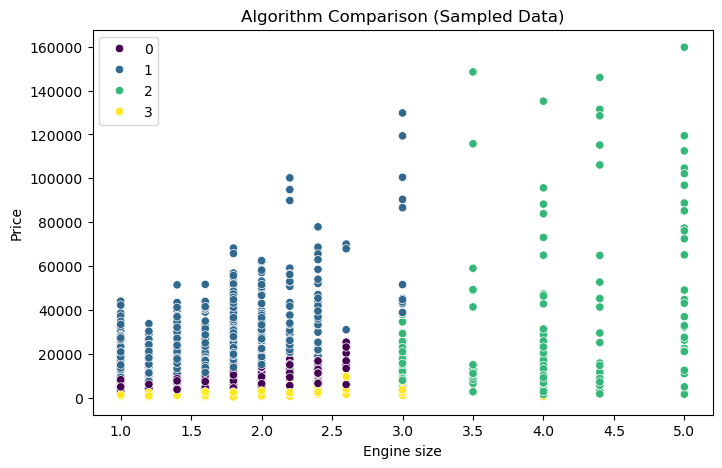

🎯 WINNER: k-Means


In [21]:
# Configuration & Speed Optimization
target_cols = ["Engine size", "Year of manufacture", "Mileage"]
k_best = 4 

# SAMPLE the data to prevent 12-minute wait times
# 2000 samples is plenty to compare algorithm performance
df_sample = df.sample(n=min(2000, len(df)), random_state=42)

X_subset = df_sample[target_cols].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_subset)

print(f"Running comparison on a sample of {len(X_subset)} rows for speed...")

# k-Means Clustering
kmeans = KMeans(n_clusters=k_best, random_state=42, n_init=10)
labels_km = kmeans.fit_predict(X_scaled)
db_km = davies_bouldin_score(X_scaled, labels_km)
sil_km = silhouette_score(X_scaled, labels_km)

# Agglomerative Clustering
agg = AgglomerativeClustering(n_clusters=k_best)
labels_agg = agg.fit_predict(X_scaled)
db_agg = davies_bouldin_score(X_scaled, labels_agg)
sil_agg = silhouette_score(X_scaled, labels_agg)

# Comparison Table
comparison_df = pd.DataFrame({
    'Method': ['k-Means', 'Agglomerative'],
    'Davies-Bouldin': [round(db_km, 4), round(db_agg, 4)],
    'Silhouette Score': [round(sil_km, 4), round(sil_agg, 4)]
})

display(comparison_df)

# Visualization
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df_sample["Engine size"], y=df_sample["Price"], hue=labels_km, palette="viridis")
plt.title("Algorithm Comparison (Sampled Data)")
plt.savefig('kmeans_comparison_scatter.png')  # Save figure
plt.show()

winner = comparison_df.loc[comparison_df['Silhouette Score'].idxmax(), 'Method']
print(f"🎯 WINNER: {winner}")